<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Javiera Yáñez Sánchez

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [70]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly

Resolved 142 packages in 33ms
Audited 137 packages in 70ms


In [71]:
import warnings

import nltk
import optuna
import pandas as pd
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [72]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [73]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [74]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [75]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [76]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

> **Respuesta:**

> Un baseline en Machine Learning es el modelo más simple (modelo base) que se usa más que nada como punto de comparación o referencia. Sirve establecerlo antes ya que fija el "mínimo esperable" aceptable de un modelo, de manera que se pueda determinar si nuevos modelos de mayor complejidad superan o no los estándares mínimos que establece el baseline.

> Se utiliza Dummy Classifier como baseline ya que es un modelo que basa sus decisiones en reglas simples o estadísticas, ignorando los datos entregados por los features, estableciendo un umbral mínimo de comparación. Que un modelo "real" no logre superar su rendimiento significa que la complejidd extra del modelo nuevo aplicado no vale la pena ser considerado si no supera las métricas basadas en el baseline (el modelo "real" no esta aprendiendo información útil).

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [77]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

# Definimos la variable objetivo
y = df_comics["alignment"]
X = df_comics.drop(columns=["alignment"])

# Separación del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Pipeline con preprocesamiento
pipeline_tree = Pipeline(
    [("preprocessing", preprocessing_transformer), ("dt_classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))]
)

# Pipeline para el Baseline
pipeline_baseline = Pipeline(
    [
        ("preprocessing", preprocessing_transformer),
        ("dummy_classifier", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    ]
)

# Entrenamiento
pipeline_tree.fit(X_train, y_train)
pipeline_baseline.fit(X_train, y_train)

# Predicciones
y_pred_tree = pipeline_tree.predict(X_test)
y_pred_baseline = pipeline_baseline.predict(X_test)

print(" BASELINE (DUMMY CLASSIFIER) ")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

print(" DECISION TREE ")
print(classification_report(y_test, y_pred_tree, zero_division=0))

 BASELINE (DUMMY CLASSIFIER) 
              precision    recall  f1-score   support

         Bad       0.32      0.34      0.33        86
        Good       0.58      0.56      0.57       148
     Neutral       0.12      0.13      0.12        23

    accuracy                           0.45       257
   macro avg       0.34      0.34      0.34       257
weighted avg       0.46      0.45      0.45       257

 DECISION TREE 
              precision    recall  f1-score   support

         Bad       0.46      0.48      0.47        86
        Good       0.66      0.62      0.64       148
     Neutral       0.11      0.13      0.12        23

    accuracy                           0.53       257
   macro avg       0.41      0.41      0.41       257
weighted avg       0.54      0.53      0.54       257



### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> **Respuesta:**

> El DT (Desicion Tree) supera al DC (Dummy Classifier) en la mayoría de aspectos. Por ejemplo, el accuracy global mejoró en casi 10 puntos; de manera similar ocurre con las clases donde el recall, precision y f1-score mejoran para las clases BAD y GOOD. Sin embargo, DT empeora - y esto se puede observar específicamente en la métrica "precision"- para la clase Neutral (clase minoritaria).

> El accuracy puede ser una métrica engañosa ya que esta ve de manera global la cantidad de aciertos que tiene el modelo, sin tomar  en cuenta el desbalance de clases -donde la clase minoritaria se puede estar prediciendo muy mal, mientras que la clase mayoritaria se predice tan bien que empaña esta métrica entregando muy buenos resultados. La métrica más apropiada para desbalance de clases es f1 score ya que corresponde al equilibrio entre reccall y precision; este trata todas las clases por igual sin importar la cantidad de casos, por lo que si una clase es mal predicha f1 score disminuye significativamente. También, puede ser recall ya que mide la proporción de casos reales de una clase que el modelo pudo predecir correctamente; el recall se utiliza si se quiere identificar de manera determinante la clase minoritaria (ej: una enfermedad rara). Finalmente, sirve también el precision ya que mide cuantas de las predicciones que el modelo hizo para una clase eran correctas, lo que asegura la confiabilidad de la clasificación.

> Se utiliza stratify en la división del dataset porque asegura que los conjuntos de entrenamiento y testeo tengan la misma proporción de cada clase que el dataset completo. Esto evita el sesgo por distribución asimétrica, si no se utilizara "stratify" podrían quedar pocos casos de la clase minoritaria en el conjunto de testeo, impidiendo evaluar correctamente el desempeño del modelo en esa clase.

> El DT si es mejor clasificador que su versión aleatoria porque mejora significativamente en las métricas globales (lo discutido anteriormente), por lo que se puede avanzar con confianza ya que es mejor que Dummy Classifier (dado de 3 caras - aleatoriedad) lo que indica que el modelo no está adivinando, si no que extrajo patrones reales y útiles a partir de los features del dataset.

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?

> **Respuesta:**


> Bagging es un algoritmo de ensamblaje que tiene como objetivo reducir la varianza. Esto lo hace mediante el entrenamiento simultáneo de varios modelos y luego combina los resultados. Sigue los siguientes tres pasos:

> 1. Generacion de subconjuntos: del dataset original se extraen subconjuntos. Cada uno es elegido por muestreo aleatorio con reemplazo, por lo que significa que si se pueden repetir instancias, de la misma manera, puede que algunas no sean seleccionadas. Por ende no se usa el dataset completo, si no que variaciones aleatorias de este.

> 2. Entrenamiento: sobre cada subconjunto se entrena un modelo predictivo base sobre todos los subconjuntos, son independientes entre si y se realiza paralelamente.

> 3. Agregación: Las predicciones de los modelos al final se combinan y por votacion mayoritaria o promedio se elige la clasificación final.

---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [78]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline Random Forest
pipeline_rf = Pipeline(
    [
        ("preprocessing", preprocessing_transformer),
        ("rf_classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]
)

# Entrenamiento
pipeline_rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = pipeline_rf.predict(X_test)

# Reporte
print("BASELINE (DUMMY CLASSIFIER)")
print(classification_report(y_test, y_pred_baseline, zero_division=0))

print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf, zero_division=0))

BASELINE (DUMMY CLASSIFIER)
              precision    recall  f1-score   support

         Bad       0.32      0.34      0.33        86
        Good       0.58      0.56      0.57       148
     Neutral       0.12      0.13      0.12        23

    accuracy                           0.45       257
   macro avg       0.34      0.34      0.34       257
weighted avg       0.46      0.45      0.45       257

RANDOM FOREST
              precision    recall  f1-score   support

         Bad       0.67      0.36      0.47        86
        Good       0.65      0.92      0.76       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.65       257
   macro avg       0.44      0.43      0.41       257
weighted avg       0.60      0.65      0.59       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:**

> Random Forest si mejoró con respecto al baseline (Dummy). Se puede observar que el accuracy global pasa de 0,45 (baseline) a 0,65 (random forest) lo que es una mejora significativa. Además, la mejora se puede observar en el F1-score de las clases mayoritarias (Bad, Good), no asi, para la clase minoritaria (Neutral) donde esta métrica cayó de 0,12 a 0,00; esto se debe a que al usarse el Bagging, se entrenan modelos en paralelo con subconjuntos, además, hay 23 ejemplo de la clase minoritaria (desbalance severo), por lo que es tan poco lo que aparece en cada subconjunto que el modelo no lo "ve" (invisible), por ende no puede aprender sobre esa clase. Lo mismo ocurre con las métricas de recall de Good (de 0,56 a 0,92), Bad (0,34 a 0,36) y Neutral (0,13 a 0,00). En cuanto al mejoramiento de algunas métricas, se debe a que el uso de bagging permite la disminución de la varianza y evita el sobreajuste que puede existir si se entrenara un árbol único.

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

> **Respuesta:**

> El algoritmo Boosting se basa en:

> 1. Entrenamiento secuencial: a diferencia del Bagging (que son entrenamientos en paralelo e independientes) Boosting entrena en serie y el modelo que sigue depende del anterior.

> 2. Correción de errores: el nuevo modelo se enfoca en los errores del modelo anterior, de manera de calcular los residuos o asignarles un mayor peso en la función de pérdida.

> 3. Predicción Final: los resultados se combinan en base a una combinación ponderada. La predicción es la suma de los resultados de cada árbol multiplicado por una tasa de aprendizaje, dándole más peso a los modelos con mejor desempeño.

> En cuanto a diferencias, XGBoost crece por niveles (de manera horizontal), dividiendo ramas completas en paralelo. LightGBM crece de manera vertical o por hojas, dividiendo solo la hoja de mayor pérdida. Además, se diferencian en que XGBoost exige etiquetas numéricas ya que calcula gradientes en la función de pérdida directamente. En cambio, LightGBM  acepta strings ya que posee un codificador categorico que transforma los strings en numericos antes del entrenamiento.

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [79]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Transformación a número
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Pipeline para XGBoost
pipeline_xgb = Pipeline(
    [
        ("preprocessing", preprocessing_transformer),
        ("xgb_classifier", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)),
    ]
)

# Pipeline para LightGBM
pipeline_lgbm = Pipeline(
    [
        ("preprocessing", preprocessing_transformer),
        ("lgbm_classifier", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
    ]
)

# Entrenamiento de los modelos
pipeline_xgb.fit(X_train, y_train_encoded)
pipeline_lgbm.fit(X_train, y_train)  # y_train sin codificar

# Predicciones
y_pred_xgb_encoded = pipeline_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

y_pred_lgbm = pipeline_lgbm.predict(X_test)

# Reporte
print("XGBOOST")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

print("LIGHTGBM")
print(classification_report(y_test, y_pred_lgbm, zero_division=0))

XGBOOST
              precision    recall  f1-score   support

         Bad       0.54      0.43      0.48        86
        Good       0.66      0.82      0.73       148
     Neutral       0.60      0.13      0.21        23

    accuracy                           0.63       257
   macro avg       0.60      0.46      0.47       257
weighted avg       0.61      0.63      0.60       257

LIGHTGBM
              precision    recall  f1-score   support

         Bad       0.59      0.53      0.56        86
        Good       0.71      0.86      0.78       148
     Neutral       1.00      0.04      0.08        23

    accuracy                           0.68       257
   macro avg       0.77      0.48      0.47       257
weighted avg       0.70      0.68      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

> **Respuesta:**

> Comparando ambos modelos, se puede concluir que el que tuvo mejor desempeño en base al accuracy (0,68) es LightGBM, reportando una mejora del F1-score en las clases Bad (de 0,48 a 0,56) y Good (0,73 a 0,78), no así con la clase Neutral (minoritaria) que empeóro en este aspecto, yendo de 0,21 a 0,08; LightGBM mejora en accuracy y en las métricas individuales en las clases mayoritarias. Sin embargo el F1-macro se mantiene igual en ambos (0,47).

> Ambos si mejoran considerablemente con respecto al baseline (F1 de 0,34 y Accuracy de 0,45); además a comparación del baseline si capturan info de las clases minoritarias, notandose en precisiones altas (0,61 y 1,00), en comparación al 0,00 de random forest y 0,12 del baseline.

> La similitud de las métricas se puede deber a que ambos usan el algoritmo Boosting, por lo que buscan la solución de la misma manera - entrenar árboles secuencialmente. En cuanto a las diferencia, estas se deben al crecimiento de árboles por hojas; mientras que XGBoost crece por niveles, LightGBM busca la hoja con mas pérdida y ahi profundiza, capturando relaciones más complejas.

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**

> A grandes rasgos, Stacking es una tecnica de ensamblado, donde se ombinan resultados de multiples modelos base para crear un nuevo modelo (meta-modelo).

> 1. Predicciones como features: los modelos base actuan como generadores de atributos. Generan predicciones sobre los datos de entrenamiento mediante validacion cruzada (para evitar data leakage), esto ya que si predijeran sonre los datos con los que fueron entrenados, el meta-modelo recibiria predicciones sobreajustadas.

> 2. Meta-modelo: este recibe como input una matriz nueva donde las columnas ya no son las variables originales, si no que las predicciones del modelo base. debe aprender a combinar y ponderar de manera estadistica las predicciones individuales para entregar el resultado. El meta-modelo evalua en qué modelos (base) confiar más y en cuales menos, en cambio los modelos base ven el problema desde cero.

> 3. Ventaja sobre eleccion simple: stacking supera a modelos individuales porque aprovecha la diversidad de los distintos algoritmos. Si un modelos es bueno detectando Good pero no Neutral, y otro es al revés (detecta mal Good y bien Neutral), el meta-modelo compensa los sesgos de cada uno, logrando que la prediccion final sea mas robusta y completa que cualquiera de los modelos base por separado.

---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [80]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier

# Modelos base
base_models = [
    ("dt", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ("lr_base", LogisticRegression(solver="lbfgs", C=0.1, max_iter=1000, random_state=RANDOM_STATE)),
    ("ridge", RidgeClassifier(random_state=RANDOM_STATE)),
]

# Meta-modelo
meta_model = LogisticRegression(random_state=RANDOM_STATE)

# Pipeline
pipeline_stacking = Pipeline(
    [
        ("preprocessing", preprocessing_transformer),
        ("stacking", StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=3, n_jobs=-1)),
    ]
)

pipeline_stacking.fit(X_train, y_train)

y_pred_stacking = pipeline_stacking.predict(X_test)

# Classification report
print("STACKING CLASSIFIER")
print(classification_report(y_test, y_pred_stacking, zero_division=0))

STACKING CLASSIFIER
              precision    recall  f1-score   support

         Bad       0.54      0.37      0.44        86
        Good       0.65      0.86      0.74       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.62       257
   macro avg       0.40      0.41      0.39       257
weighted avg       0.55      0.62      0.57       257



### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**

> **Modelos base (elegidos):**
> - **DecisionTreeClassifier:** captura relaciones no lineales entre features. Limitando la profundidad se evita sobreajuste y aporta diversidad de errores.
> - **LogisticRegression:** es un modelo lineal que aporta una perspectiva distinta a la del árbol. Es útil cuando las clases tienen separabilidad lineal en el espacio de features.
> - **RidgeClassifier:** complementa a LR con una formulación distinta (regularización L2 directa), aportando diversidad sin agregar demasiada complejidad.

> Se eligió el meta modelo LogisticRegression porque es simple e interpretable, y aprende a ponderar linealmente las salidas de los modelos base sin sobreajustarse a ellas.

> El stacking no mejoró con respecto a los modelos base individuales de las secciones anteriores, sin tomar el cuenta de que si supera al modelo baseline Dummy. El F1-Macro del Stacking (0.39) es inferior al de XGBoost y LightGBM (0.47), e incluso similar al DecisionTree simple. La clase Neutral obtiene F1 = 0, igual que RandomForest.

> Esto se explica por como funciona el algoritmo. Como el meta-modelo solo puede combinar lo que los modelos base le dicen, si los tres modelos base no pueden distinguir la clase minoritaria (Neutral), es información que el meta-modelo no recibe, por ende no puede "saber" la existencia de esta clase. El stacking es tan bueno como sus modelos base, y en este caso usar clasificadores simples fue una desventaja frente a los métodos de boosting, que iterativamente corrigen sus propios errores.

---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

> **Respuesta:**

> 1. Los hiperparámetros son las configuraciones que se pueden hacer al modelo antes del entrenamiento que controlan el aprendizaje(por ejemplo, learning_rate, max_depth, n_estimators, etc.) y son propias de cada modelo. Por otro lado, los parámetros son los valores que el modelo aprende durante el entrenamiento a partir de los datos, estos son, por ejemplo, los pesos de los nodos de un arbol o los coeficientes de regresión.

> 2. Es importante optimizarlos ya que existen ciertas combinaciones de hiperparámetros que dan mejores resultados que otros. Los que vienen por defecto son genéricos y pueden no ser los adecuados para el problema en especifico, lo que puede llevar a un sobreajuste o subajuste por parte del modelo hacia los datos, afectando las métricas de evaluación.

> 3. GridSearchCV evalua exhaustivamente todas las combinaciones posibles de un grid dado (catálogo de hiperparametros a probar), usando CV para estimar el rendimiento de cada combinación. Su principal limitación es el aumento explosivo de la cantidad de combinaciones al evaluar, y computacionalmente no sería viable (mucho tiempo de ejecución). Por ejemplo si se tienen 6 hiperparámetros con 8 opciones cada uno, serian cerca de 262.000 combinaciones (tardaría mucho la evaluación).

> 4. Se usa CV porque si se usara el test para seleccionar los hiperparametros existiría data leakage. La informacion que esta contenida en el test se filtraría para elegir los mejores hiperparámetros; luego la evaluación final estaría sesgada y no representaría los datos reales. Se podría reemplazar con hold-out de validación separado, que es más rápido pero tiene mayor varianza en la estimación y menos datos para el entrenamiento.

> 5. TPE es superior a GridSearch porque no explora exhaustivamente cada combinación, si no que modela qué regiones de hiperparámetros han dado buenos resultados y propone nuevas combinaciones cercanas a esas zonas; permitiendo explorar espacios con menos combinaciones siendo mas eficiente.

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [81]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [82]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 75. Best value: 0.457592: 100%|██████████| 50/50 [32:05<00:00, 38.51s/it]

Mejor F1-Macro: 0.4576

Mejores hiperparámetros:
  num_leaves: 89
  learning_rate: 0.20502463741881424
  max_depth: 6
  min_child_samples: 24
  subsample: 0.7134573576568636
  colsample_bytree: 0.7976464962363403
  reg_alpha: 8.572937091292236e-05
  reg_lambda: 0.0004218077468337763


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [83]:
import optuna.visualization as vis

# Historial de optimizacion
fig_history = vis.plot_optimization_history(study)
fig_history.update_layout(title="Historial de Optimización - LightGBM")
fig_history.show()

# Importancia de hiperparámetros
fig_importance = vis.plot_param_importances(study)
fig_importance.update_layout(title="Importancia de Hiperparámetros")
fig_importance.show()

# Coordenadas paralelas
fig_parallel = vis.plot_parallel_coordinate(study)
fig_parallel.update_layout(title="Coordenadas Paralelas - Hiperparámetros")
fig_parallel.show()

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [84]:
from sklearn.metrics import f1_score

# Pipeline con los mejores hiperparametros encontrados
pipe_lgbm_opt = Pipeline(
    [
        ("preprocessing", preprocessing_transformer),
        ("lgbm_opt", LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)),
    ]
)

# Entrenamiento
pipe_lgbm_opt.fit(X_train, y_train)

# Predicciones
y_pred_lgbm_opt = pipe_lgbm_opt.predict(X_test)

# Comparacion f1
f1_default = f1_score(y_test, y_pred_lgbm, average="macro")
f1_opt = f1_score(y_test, y_pred_lgbm_opt, average="macro")

print(f"F1-Macro LightGBM (defaults): {f1_default:.4f}")
print(f"F1-Macro LightGBM (optimizado): {f1_opt:.4f}")
print(f"Mejora: {f1_opt - f1_default:+.4f}")

print("Reporte LGBM Optimizado:")
print(classification_report(y_test, y_pred_lgbm_opt, zero_division=0))

F1-Macro LightGBM (defaults): 0.4745
F1-Macro LightGBM (optimizado): 0.4599
Mejora: -0.0146
Reporte LGBM Optimizado:
              precision    recall  f1-score   support

         Bad       0.56      0.51      0.53        86
        Good       0.70      0.84      0.76       148
     Neutral       1.00      0.04      0.08        23

    accuracy                           0.66       257
   macro avg       0.75      0.46      0.46       257
weighted avg       0.68      0.66      0.63       257



### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

> 1. Segun plot_param_importances, el hiperparámetro que tuvo mas impacto fue learning_rate, lo que tiene sentido en boosting ya que learning_rate controla cuánto contribuye cada arbol en la predicción final; un valor muy alto lleva a overfitting y uno mas bajo necesita mas arboles para converger. 

> 2. plot_parallel_coordinate entrega mayor información que los logs de texto. La información adicional que entrega es que se puede observar las interacciones ocultas, la sensibilidad de los parámetros (se identifica rápido que variables son críticas y se ahorra el tiempo de estar viendo texto por texto como el logs de texto). El historial de optimización muestra cómo mejora el mejor valor encontrado trial a trial, permitiendo ver si el estudio convergió. Al seleccionar en plot_parallel_coordinate los trials con mayor Objective Value (0.45), se observa que los mejores resultados se asocian a learning_rate bajo-medio (0.01-0.1), num_leaves alto (>100), max_depth cercano a 12, y colsample_bytree/subsample altos (>0.8). En cambio, reg_alpha y reg_lambda no muestran patrón claro, sugiriendo que la regularización tiene poco impacto en este dataset.

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [85]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparametros, solo sobre scores numericos
lgbm_interp = LGBMClassifier(**study.best_params, random_state=RANDOM_STATE, verbose=-1)
lgbm_interp.fit(X_train_num, y_train)

print("Modelo auxiliar para interpretabilidad:")
print(f"Features: {NUMERICAL_FEATURES}")
print(f"Clases: {lgbm_interp.classes_}")

Modelo auxiliar para interpretabilidad:
Features: ['intelligence_score', 'strength_score', 'speed_score', 'durability_score', 'power_score', 'combat_score']
Clases: ['Bad' 'Good' 'Neutral']


## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**

> 1. PFI entrena un modelo y mide su rendimiento base (cualquier métrica de interés, ej: f1) en el conjunto test. Para cada variable se permutan (mezclan) los valores de esa columna en el conjunto test, rompiendo la relacion entre las variables y la variable objetivo. Luego, vuelve a medir el rendimiento del modelo con la variable permutada; para despues medir la importancia de la variable (feature) en base a la caida en el rendimiento (si cae mucho el rendimiento la feature es importante). Repite varias veces para obtener la varianza de la importancia de la feature.

> 2. Se prefiere PFI debido a que la importancia nativa de los árboles (basado en impureza-gini) tiene sesgo hacia las features de muchos valores únicos: el arbol prefiere estas features porque ofrecen más puntos de corte, no porque necesariamente aporten mas informacion. PFI evita este sesgo porque mide sobre el rendimiento de los datos del test, independiente de la contrucción del árbol.

---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [86]:
import plotly.express as px
from sklearn.inspection import permutation_importance

# Calcular pfi
pfi_result = permutation_importance(
    lgbm_interp, X_test_num, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="f1_macro"
)

# Importancias y desviacion estandar
pfi_df = pd.DataFrame(
    {
        "feature": NUMERICAL_FEATURES,
        "importance_mean": pfi_result.importances_mean,
        "importance_std": pfi_result.importances_std,
    }
).sort_values("importance_mean", ascending=True)

# Graficar barplot horizontal
fig = px.bar(
    pfi_df,
    x="importance_mean",
    y="feature",
    orientation="h",
    error_x="importance_std",
    title="Permutation Feature Importance (F1-Macro)",
    labels={"importance_mean": "Importancia media (caída en F1-Macro)", "feature": "Feature"},
    color="importance_mean",
    color_continuous_scale="Blues",
)
fig.update_layout(coloraxis_showscale=False, height=400)
fig.show()

### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**

> Segun el grafico, la feature que tuvo mayor importancia es combat_score, ya que es la que tiene mayor caida de F1. Tiene sentido hasta cierto punto, generalmente los comics el héroe es el que gana en los combates; sin embargo, no aplicaría si es que el villano es el que gana (significaria que este tiene mayor puntaje de combate). 

> Me sorprende speed_score y durability_score ya que son características compartidas entre héroes y villanos de distintos universos sin un patrón claro por alineación, por lo que uno intuitivamente sentiria que estos datos no entregarían mucha información ya que pueden estar muy a la par ambas clases.

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**

> 1. Los Shap Values miden la contribucion individual de cada variable a la predicción de una clase. A diferencia del PFI, que es una medida global de importancia, el Shap es local, es decir, explica por qué el modelo predijo lo que predijo para cada instancia individual, mostrando la magnitud y dirección del efecto de cada feature en esa prediccion en específico.

> 2. Esto representa la predicción promedio del modelo sobre el conjunto de entrenamiento. Es el punto de partida ya que los shap values muestran como cada feature mueve la predicción del valor base hacia el valor final. La suma de los Shap values con base_values es igual a la predicción del modelo en esa instancia.

> 3. TreExplainer esta hecho especificamente para modelos basados en árboles, aprovechando esa estructura para calcular Shap values de forma exacta y eficiente. Un explainer genérico requiere muestreo aleatorio y es más lento, ya que no conoce la estructura interna del modelo.

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

Clases del modelo: ['Bad', 'Good', 'Neutral']
Índice clase Good: 1

--- Summary Plot (clase Good) ---


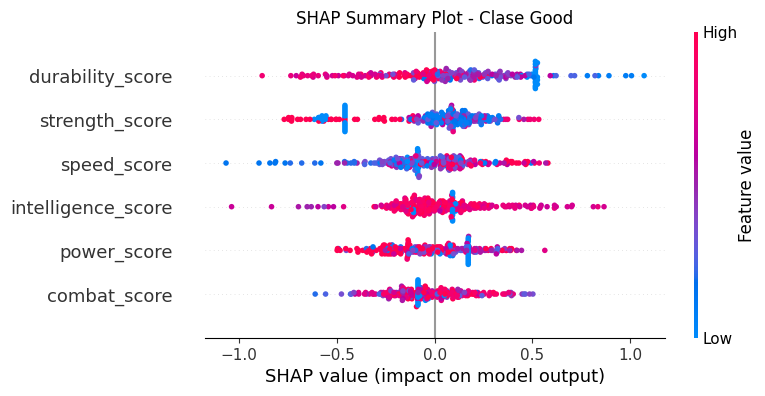


--- Waterfall Plot (primera instancia) ---
Personaje: The Shocker (MCU)
Alineación real: Bad
Predicción: Bad


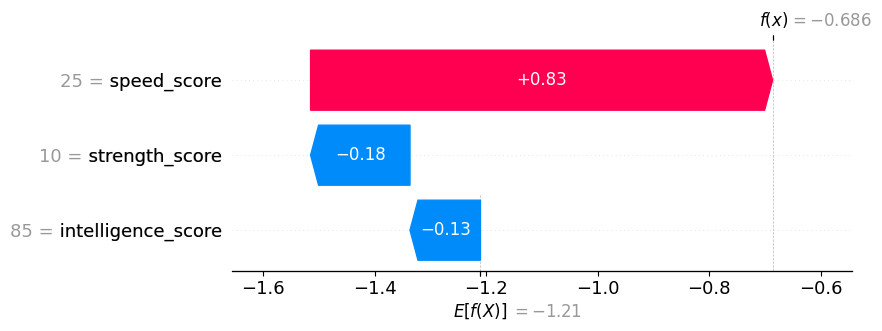

In [87]:
import matplotlib.pyplot as plt
import shap

# Crear el TreeExplainer
explainer = shap.TreeExplainer(lgbm_interp)  # objeto explicador

# Calcular shap values sobre X_test_num para cada dato
shap_values = explainer.shap_values(X_test_num)  # cuanto contribuyó cada caracteritica

# Obtener el indice de la clase Good
classes = list(lgbm_interp.classes_)
good_idx = classes.index("Good")  # posicion de la clase Good
print(f"Clases del modelo: {classes}")
print(f"Índice clase Good: {good_idx}")

# Summary plot para la clase Good
print("\n--- Summary Plot (clase Good) ---")
shap.summary_plot(
    shap_values[:, :, good_idx], X_test_num, feature_names=NUMERICAL_FEATURES, show=False
)  # filtro solo usar lo de good

plt.title("SHAP Summary Plot - Clase Good")
plt.show()

# Waterfall plot para la primera instancia del test set (Vista local)
print("\n--- Waterfall Plot (primera instancia) ---")
instance_idx = 0  # primer personaje

# Obtener prediccion y su indice
pred_class = lgbm_interp.predict(X_test_num.iloc[[instance_idx]])[0]  # prediccion para primer personaje
pred_idx = classes.index(pred_class)  # verdadero indice del personaje

print(f"Personaje: {X_test.iloc[instance_idx]['name'] if 'name' in X_test.columns else X_test_num.index[instance_idx]}")
print(f"Alineación real: {y_test.iloc[instance_idx]}")
print(f"Predicción: {pred_class}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[pred_idx][instance_idx],  # valores shap
        base_values=explainer.expected_value[pred_idx],  # valor esperado
        data=X_test_num.iloc[instance_idx].values,  # valores reales
        feature_names=NUMERICAL_FEATURES,
    )
)

### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**

> 1. La diferencia entre un PFI y un Shap es que PFI es una metrica global (mira la caida de F1 de cada feature sobre el test) y Shap es local y global, es decir, explica cuánto y en que direccion contribuyó cada feature en la prediccion.

> 2. Las features que mas empujaron en la prediccion fueron: strenght_score (+0,21 hacia Good) e intelligence_score ( - 0,31 hacia Bad). Sin embargo el modelo predijo que era Good cuando en realidad era Bad. El villano Shocker de Spiderman tiene harto poder físico pero poca inteligencia. El modelo interpretó su baja inteligencia con Bad, sin embargo, el strenght score bajo lo tiró para Good. Esto muestra una limitación, que los features numericos no logran captar por si solos la intencion de cada heroe o villano.

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [88]:
# Cargar dataset sin etiquetas
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)

# Eliminar NaN en history_text
df_no_label_clean = df_comics_no_label.dropna(subset=["history_text"]).copy()

# Predecir usando el mejor modelo
df_no_label_clean["alignment_pred"] = pipe_lgbm_opt.predict(df_no_label_clean)

# Filtrar los personajes de interés
personajes_interes = ["Vergil", "Gorilla Girl", "Bat-Cow"]
resultado = df_no_label_clean[df_no_label_clean["name"].isin(personajes_interes)][["name", "alignment_pred"]]

print("Predicciones de alineación:")
print(resultado.to_string(index=False))

Predicciones de alineación:
        name alignment_pred
Gorilla Girl           Good
      Vergil           Good


### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

> **Respuesta:**

> 1. Gorilla girl es una heroina de marvel y el modelo la clasificó como Good; Vergil es la antagonista de DEvil May Cry, donde quiere el poder absoluto, sin embargo el modelo la clasificó como Good cuando correspondeia a Bad. Esto se puede deber a que quizas en el history_text su descripción se parezca a la de los héroes. Y en cambio, Bat-Cow no pudo ser predicha ya que aparentemente no tiene history_text y esas filas se eliminaron (Nan), entonces el modelo no tiene informacion suficiente para clasificarlo.

> 2. De Bat-cow se esperaría que obtuviera scores bajos en Intelligence y Strenght (features influyentes segun waterfall), lo que probablemente la tiraria hacia Neutral o Good, que tiene sentido ya que su personaje es inofensivo.

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>